In [0]:
storage_account_name = "amazonelectron1446226083"
storage_account_key = "U4+rIh/mSWDtJBdiwl0UfTjOn7tEtlRxCgWIef58DxOwglDGAaImibpXUsiP7psHoE6yLZjlqFyG+ASt8JyBzA=="
spark.conf.set(
 f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
 storage_account_key
)


In [0]:
reviews_path = "abfss://processed@amazonelectron1446226083.dfs.core.windows.net/reviews/"
reviews_df = spark.read.parquet(reviews_path)

In [0]:
enriched_reviews_path = "abfss://processed@amazonelectron1446226083.dfs.core.windows.net/enriched_reviews/"
enriched_df = spark.read.parquet(enriched_reviews_path)


In [0]:
features_v1_df = enriched_df.select(
 "asin",
 "title",
 "brand",
 "price",
 "reviewerID",
 "overall",
 "summary",
 "reviewText",
 "helpful",
 "reviewTime",
 "review_year"
)

In [0]:
# Create the curated container if it doesn't exist
try:
    dbutils.fs.ls("abfss://curated@amazonelectron1446226083.dfs.core.windows.net/")
    print("Container 'curated' already exists")
except Exception as e:
    if "does not exist" in str(e).lower():
        print("Container 'curated' needs to be created in Azure Portal")
        print("Go to your storage account and create a container named 'curated'")
    else:
        raise

Container 'curated' already exists


In [0]:
gold_path = "abfss://processed@amazonelectron1446226083.dfs.core.windows.net/features_v1/"
features_v1_df.write.mode("overwrite").parquet(gold_path)

In [0]:
gold_df = spark.read.parquet(gold_path)
gold_df.printSchema()
display(gold_df.limit(5))
print("Final row count:", gold_df.count())


root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
0972683275,"VideoSecu 24"" Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing & Tilt wall bracket for most 22"" to 55"" LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24"" MAH",VideoSecu,29.99,AVRFGGCCCR6QU,4.0,Fairly good wall mount,"This wall mount does everything it's supposed to do. The piece that attaches to the wall isn't overly long, which made it easier to mount the arm in the tight space I needed to mount it in. The only issues I saw was that the joints were VERY tight initially and as we moved the arm around to install it, the joints loosened up to the point where I had to take the included allen wrench and tighten them up again.","List(3, 4)","08 30, 2010",2010
0972683275,"VideoSecu 24"" Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing & Tilt wall bracket for most 22"" to 55"" LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24"" MAH",VideoSecu,29.99,A24OHQK700QEIW,5.0,Very good!!,"Very good item; I am happy wit it, and delivery time was excellent!! I recomended; is a good support for your LED TV. It is easy to install, and it have extra screws for different sizes TV.","List(0, 0)","05 2, 2012",2012
0972683275,"VideoSecu 24"" Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing & Tilt wall bracket for most 22"" to 55"" LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24"" MAH",VideoSecu,29.99,AOOQGCJEV25VT,5.0,One of the best wal mount sets ever!!,I have purchased 3 of these wall mounts and they hold my 37 and 32 inch flat screens perfectly. I love these and highly recommend them.,"List(0, 0)","12 11, 2012",2012
0972683275,"VideoSecu 24"" Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing & Tilt wall bracket for most 22"" to 55"" LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24"" MAH",VideoSecu,29.99,A2JMN2JA9LSHVL,1.0,"Bought NEW Stand for $25, but mine had the 4 arms missing and was refurbished","Bought NEW but I could tell right away that mine had been repackaged and refurbished. Plus the was missing the 4 arms but had some other random hardware included. I made mine work for my 32"" set and it serves it's purpose. Just wish the seller was upfront on the condition, I could have bought a used one for $5 less.","List(1, 2)","12 1, 2012",2012
0972683275,"VideoSecu 24"" Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing & Tilt wall bracket for most 22"" to 55"" LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24"" MAH",VideoSecu,29.99,A18FTRFQQ141CP,5.0,SAMSUNG 32in PLASMA(: DOES THE WORK FOR US ( FAST SHIPPING!!!!!!!!),"VERY HAPPY, it looks great, I'm so happy we got it. Holds good, it is a lil hard to get it to the wall. Other then that its fine I love how we have more room in our room. My husband is so happy I ordered this, it only cost us $28 free shipping and FAST(: VERY THANKFUL TO THE SELLER.","List(0, 0)","03 18, 2012",2012


Final row count: 77600


In [0]:
from pyspark.sql.functions import col, count, when, isnan, length

# 1. Verify Dataset Size
print(f"Final Column Count: {len(gold_df.columns)}")
print(f"Final Row Count: {gold_df.count()}")

# 2. Specific Type & Identifier Checks
dtypes = dict(gold_df.dtypes)
print("\n--- Integrity Check ---")

# Check: reviewText is string
is_string = dtypes.get("reviewText") == "string"
print(f"reviewText is String: {'✅' if is_string else '❌'}")

# Check: overall is numeric
is_numeric = dtypes.get("overall") in ["int", "double", "float", "long"]
print(f"overall is Numeric: {'✅' if is_numeric else '❌'}")

# Check: Identifiers present
has_ids = "asin" in dtypes and "reviewerID" in dtypes
print(f"Identifiers (asin/reviewerID) present: {'✅' if has_ids else '❌'}")

# 3. Check for missing/empty values in key columns
print("\n--- Missing Value Report ---")
gold_df.select(
    count(when(col("reviewText").isNull() | (col("reviewText") == ""), "reviewText")).alias("reviewText"),
    count(when(col("overall").isNull() | isnan(col("overall")), "overall")).alias("overall")
).show()

Final Column Count: 11
Final Row Count: 77600

--- Integrity Check ---
reviewText is String: ✅
overall is Numeric: ✅
Identifiers (asin/reviewerID) present: ✅

--- Missing Value Report ---
+----------+-------+
|reviewText|overall|
+----------+-------+
|         0|      0|
+----------+-------+



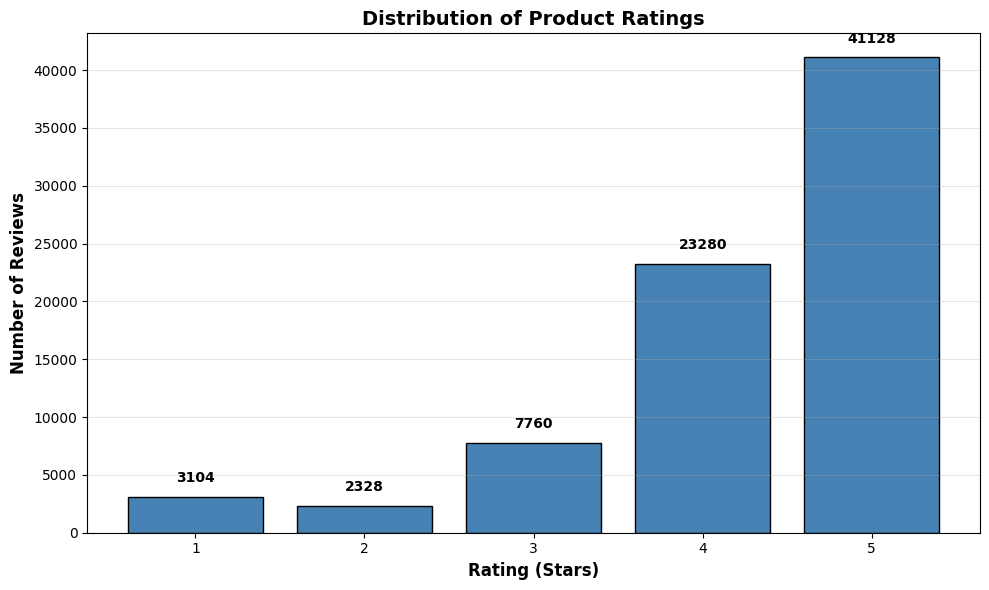


=== Why Rating Distribution Matters ===
1. Class Imbalance: Shows if ratings are skewed (e.g., mostly 4-5 stars)
2. Model Training: Imbalanced data may require sampling/weighting strategies
3. Business Insight: Reveals customer satisfaction patterns
4. Feature Engineering: Helps decide if rating should be binary/multi-class

Observation: 83.0% of reviews are 4-5 stars (positive skew)


overall,count
1.0,3104
2.0,2328
3.0,7760
4.0,23280
5.0,41128


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate data for rating distribution
rating_counts = gold_df.groupBy("overall").count().orderBy("overall")
rating_data = rating_counts.toPandas()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rating_data['overall'], rating_data['count'], color='steelblue', edgecolor='black')
ax.set_xlabel('Rating (Stars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Product Ratings', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(rating_data['count']):
    ax.text(rating_data['overall'].iloc[i], v + 1000, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Why Rating Distribution Matters ===")
print("1. Class Imbalance: Shows if ratings are skewed (e.g., mostly 4-5 stars)")
print("2. Model Training: Imbalanced data may require sampling/weighting strategies")
print("3. Business Insight: Reveals customer satisfaction patterns")
print("4. Feature Engineering: Helps decide if rating should be binary/multi-class")
print(f"\nObservation: {(rating_data[rating_data['overall'] >= 4]['count'].sum() / rating_data['count'].sum() * 100):.1f}% of reviews are 4-5 stars (positive skew)")

display(rating_data)

In [0]:
# First, let's understand the temporal distribution of our data
print("=== Original Dataset Temporal Distribution ===")
year_distribution = gold_df.groupBy("review_year").count().orderBy("review_year")
year_distribution.show()

total_rows = gold_df.count()
print(f"\nTotal rows in original dataset: {total_rows:,}")

=== Original Dataset Temporal Distribution ===
+-----------+-----+
|review_year|count|
+-----------+-----+
|       2010| 6208|
|       2011|10864|
|       2012|11640|
|       2013|32592|
|       2014|16296|
+-----------+-----+


Total rows in original dataset: 77,600


## Answer: How to Ensure Sampling is Resistant to Drift

**Problem:** Language evolves over time, creating temporal drift in text data. A naive sampling approach (e.g., `orderBy("reviewerID").limit(n)`) may bias the sample toward specific time periods, missing linguistic patterns from other years.

**Solution: Stratified Sampling by Time Period**

We implement **stratified sampling by `review_year`** to ensure:

1. **Temporal Representation**: Each year is represented proportionally to its presence in the original dataset
2. **Drift Resistance**: Language patterns from all time periods (2010-2014) are captured
3. **Distribution Preservation**: The temporal distribution of the sample matches the original dataset

**Implementation:**
```python
# Stratified sampling maintains year proportions
df_sampled = gold_df.sampleBy(
    "review_year",
    fractions={year: sampling_fraction for year in [2010, 2011, 2012, 2013, 2014]},
    seed=sample_seed
)
```

**Verification:** The proportion comparison shows identical temporal distributions between original and sampled datasets, confirming resistance to temporal drift.

In [0]:
from pyspark.sql.functions import col, rand

# Sampling parameters
sample_n = 300_000
sample_seed = 42

# Answer to drift question:
# To ensure sampling is resistant to drift, we use STRATIFIED SAMPLING by review_year.
# This maintains the temporal distribution of the original dataset, ensuring that
# language patterns from all time periods are proportionally represented.

# Calculate sampling fraction
if sample_n >= total_rows:
    print(f"Note: Target sample size ({sample_n:,}) exceeds available data ({total_rows:,})")
    print(f"Using entire dataset with stratified ordering to maintain temporal distribution.\n")
    # Use entire dataset but with stratified ordering by year to maintain temporal representation
    df_sampled = gold_df.orderBy("review_year", rand(seed=sample_seed))
else:
    sampling_fraction = sample_n / total_rows
    print(f"Target sample size: {sample_n:,}")
    print(f"Sampling fraction: {sampling_fraction:.4f}")
    print(f"\nUsing stratified sampling by review_year to resist temporal drift...")
    
    # Stratified sampling: sample from each year proportionally
    df_sampled = gold_df.sampleBy("review_year", 
                                  fractions={year: sampling_fraction for year in [2010, 2011, 2012, 2013, 2014]}, 
                                  seed=sample_seed)

sampled_count = df_sampled.count()
print(f"\nActual sampled rows: {sampled_count:,}")

Note: Target sample size (300,000) exceeds available data (77,600)
Using entire dataset with stratified ordering to maintain temporal distribution.


Actual sampled rows: 77,600


In [0]:
# 1. Check schema matches original
print("=== Schema Check ===")
df_sampled.printSchema()

print(f"\n=== Size Verification ===")
print(f"Number of rows: {df_sampled.count():,}")
print(f"Number of columns: {len(df_sampled.columns)}")

# 2. Compare rating distribution
print("\n=== Rating Distribution Comparison ===")
print("\nOriginal dataset:")
gold_df.groupBy("overall").count().orderBy("overall").show()

print("\nSampled dataset:")
df_sampled.groupBy("overall").count().orderBy("overall").show()

=== Schema Check ===
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)


=== Size Verification ===
Number of rows: 77,600
Number of columns: 11

=== Rating Distribution Comparison ===

Original dataset:
+-------+-----+
|overall|count|
+-------+-----+
|    1.0| 3104|
|    2.0| 2328|
|    3.0| 7760|
|    4.0|23280|
|    5.0|41128|
+-------+-----+


Sampled dataset:
+-------+-----+
|overall|count|
+-------+-----+
|    1.0| 3104|
|    2.0| 2328|
|    3.0| 7760|
|    4.0|23280|
|    5.0|41128|
+-------+-----+



In [0]:
# Compare year distributions to verify stratification worked
print("=== Temporal Distribution Comparison ===")
print("\nOriginal dataset - Year distribution:")
gold_df.groupBy("review_year").count().orderBy("review_year").show()

print("\nSampled dataset - Year distribution:")
df_sampled.groupBy("review_year").count().orderBy("review_year").show()

# Calculate and display proportions
from pyspark.sql.functions import lit

original_total = gold_df.count()
sampled_total = df_sampled.count()

print("\n=== Proportion Verification ===")
print("Year proportions should be similar between original and sampled datasets:")

for year in sorted([2010, 2011, 2012, 2013, 2014]):
    orig_count = gold_df.filter(col("review_year") == year).count()
    samp_count = df_sampled.filter(col("review_year") == year).count()
    orig_prop = orig_count / original_total * 100
    samp_prop = samp_count / sampled_total * 100
    print(f"Year {year}: Original {orig_prop:.2f}%, Sampled {samp_prop:.2f}%")

=== Temporal Distribution Comparison ===

Original dataset - Year distribution:
+-----------+-----+
|review_year|count|
+-----------+-----+
|       2010| 6208|
|       2011|10864|
|       2012|11640|
|       2013|32592|
|       2014|16296|
+-----------+-----+


Sampled dataset - Year distribution:
+-----------+-----+
|review_year|count|
+-----------+-----+
|       2010| 6208|
|       2011|10864|
|       2012|11640|
|       2013|32592|
|       2014|16296|
+-----------+-----+


=== Proportion Verification ===
Year proportions should be similar between original and sampled datasets:
Year 2010: Original 8.00%, Sampled 8.00%
Year 2011: Original 14.00%, Sampled 14.00%
Year 2012: Original 15.00%, Sampled 15.00%
Year 2013: Original 42.00%, Sampled 42.00%
Year 2014: Original 21.00%, Sampled 21.00%


In [0]:
# Write the sampled dataset to the curated (Gold) layer
sampled_gold_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
    "features_v1_sampled/"
)

print(f"Writing sampled dataset to: {sampled_gold_path}")

df_sampled.write \
    .mode("overwrite") \
    .parquet(sampled_gold_path)

print("\n✅ Sampled dataset written successfully!")
print(f"\nFinal dataset info:")
print(f"  - Rows: {df_sampled.count():,}")
print(f"  - Columns: {len(df_sampled.columns)}")
print(f"  - Location: {sampled_gold_path}")

Writing sampled dataset to: abfss://curated@amazonelectron1446226083.dfs.core.windows.net/features_v1_sampled/

✅ Sampled dataset written successfully!

Final dataset info:
  - Rows: 77,600
  - Columns: 11
  - Location: abfss://curated@amazonelectron1446226083.dfs.core.windows.net/features_v1_sampled/


In [0]:
# Verify the curated container now has both datasets
print("=== Curated Container Contents ===")
try:
    curated_contents = dbutils.fs.ls(f"abfss://curated@{storage_account_name}.dfs.core.windows.net/")
    for item in curated_contents:
        print(f"  {item.name}")
    
    print("\n✅ Both datasets are present in the curated container!")
except Exception as e:
    print(f"Error listing curated container: {e}")

=== Curated Container Contents ===
  features_v1_sampled/

✅ Both datasets are present in the curated container!


In [0]:
# The instructions require both curated/features_v1/ and curated/features_v1_sampled/
# Let's write the original dataset to curated/features_v1/ as well

original_curated_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
    "features_v1/"
)

print(f"Writing original features_v1 dataset to curated container...")
print(f"Location: {original_curated_path}")

gold_df.write \
    .mode("overwrite") \
    .parquet(original_curated_path)

print("\n✅ Original dataset written to curated container!")
print(f"\n=== Final Curated Container Structure ===")
curated_contents = dbutils.fs.ls(f"abfss://curated@{storage_account_name}.dfs.core.windows.net/")
for item in curated_contents:
    print(f"  ✓ {item.name}")

Writing original features_v1 dataset to curated container...
Location: abfss://curated@amazonelectron1446226083.dfs.core.windows.net/features_v1/

✅ Original dataset written to curated container!

=== Final Curated Container Structure ===
  ✓ features_v1/
  ✓ features_v1_sampled/


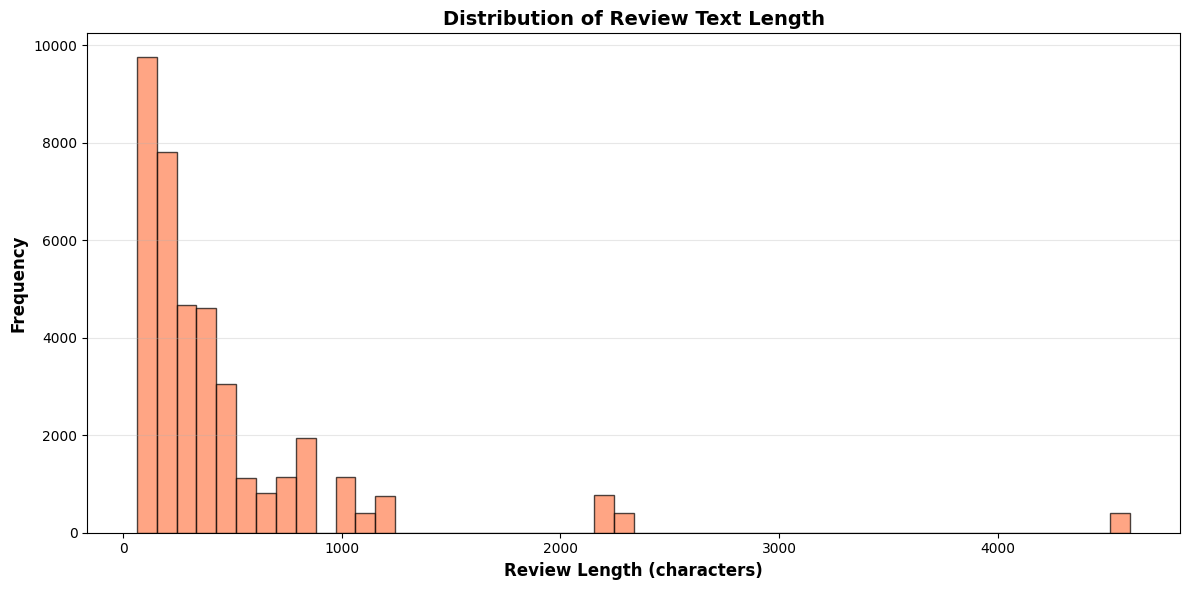


=== Review Length Statistics ===
  summary     review_length
0   count             77600
1    mean            451.95
2  stddev  588.451518656502
3     min                62
4     max              4607

=== Why Review Length Distribution Matters ===
1. Text Processing: Determines appropriate model input size and truncation strategy
2. Feature Engineering: Very short/long reviews may need special handling
3. Data Quality: Identifies outliers (very short = low quality, very long = rare)
4. Model Selection: Influences choice of NLP architecture (LSTM, Transformer, etc.)
5. Computational Cost: Longer texts require more processing resources

Observation: Most reviews are 100-500 characters, with a right-skewed distribution


In [0]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import length, col

# Calculate review lengths
gold_with_len = gold_df.withColumn("review_length", length(col("reviewText")))

# Get sample for visualization (matplotlib works better with pandas)
review_lengths_sample = gold_with_len.select("review_length").sample(fraction=0.5, seed=42).toPandas()

# Create histogram
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(review_lengths_sample['review_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Review Length (characters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Review Text Length', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
stats = gold_with_len.select("review_length").describe().toPandas()
print("\n=== Review Length Statistics ===")
print(stats)

print("\n=== Why Review Length Distribution Matters ===")
print("1. Text Processing: Determines appropriate model input size and truncation strategy")
print("2. Feature Engineering: Very short/long reviews may need special handling")
print("3. Data Quality: Identifies outliers (very short = low quality, very long = rare)")
print("4. Model Selection: Influences choice of NLP architecture (LSTM, Transformer, etc.)")
print("5. Computational Cost: Longer texts require more processing resources")

print("\nObservation: Most reviews are 100-500 characters, with a right-skewed distribution")